# Proyecto Final - Sistema Inteligente de Recomendación para E-commerce

# Notebook 06: Sistema de Recomendación

## Objetivo

Diseñar, entrenar e implementar un sistema de recomendación capaz de sugerir productos personalizados a los usuarios a partir de su historial de navegación, compras, preferencias e interacciones registradas en la plataforma de comercio electrónico.

Este modelo constituye la solución principal del proyecto y busca mejorar la experiencia del usuario mediante recomendaciones relevantes y personalizadas.

---

## Objetivos específicos

- Construir modelos de recomendación basados en diferentes enfoques.
- Comparar el desempeño de cada modelo.
- Seleccionar el modelo con mejores resultados.
- Generar recomendaciones personalizadas para cada usuario.

---

## Datos utilizados

- Dataset preparado en el Notebook 04.
- Variables creadas durante Feature Engineering.
- Información de clientes.
- Productos.
- Órdenes.
- Eventos.
- Reviews.

---

## Modelos implementados

| Integrante | Modelo |
|------------|---------|
| **Yustin** | Baseline (Popularidad) |
| **Elías** | Content-Based Filtering |
| **Carina** | Collaborative Filtering |
| **Rocío** | Modelo híbrido y comparación final |

---

## Resultado esperado

Desarrollar un sistema capaz de generar recomendaciones relevantes para cada usuario utilizando diferentes técnicas de recomendación y seleccionar el modelo con mejor desempeño para su implementación.

---

**Metodología:** CRISP-DM

**Sprint:** 1 – Modelado

## Flujo de entrenamiento con LightGBM y XGBoost

Este notebook implementa un primer pipeline de recomendación usando datos preparados previamente por el feature engineering.

### Pasos que se van a realizar
1. Cargar la matriz usuario-producto y los features derivados.
2. Construir ejemplos positivos y negativos para entrenar un modelo de clasificación binaria.
3. Separar los datos en train y test.
4. Entrenar dos modelos:
   - LightGBM
   - XGBoost
5. Medir el desempeño con:
   - accuracy
   - precision
   - recall
   - f1
   - MAP@K
   - NDCG@K
6. Comparar los resultados para elegir el modelo inicial más prometedor.

La idea es empezar con un enfoque simple y reproducible antes de pasar a modelos más complejos.

In [1]:
import os
import sys
from pathlib import Path

NOTEBOOK_DIR = Path.cwd()
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.append(str(NOTEBOOK_DIR))

sys.path.append(str(NOTEBOOK_DIR.parent))

from SRC.feature_engineering import generar_features

interaction_matrix, product_features, user_features, user_item_df, events_con_user = generar_features()

print("Matriz usuario-item:", interaction_matrix.shape)
print("Features producto:", product_features.shape)
print("Features usuario:", user_features.shape)
print("DataFrame usuario-item:", user_item_df.shape)


############################################################
# PIPELINE DE FEATURE ENGINEERING
############################################################

############################################################
# PIPELINE DE LIMPIEZA DE DATOS
############################################################

Cargando datos...



Archivo cargado correctamente: events.csv
Dimensiones: 760958 filas x 10 columnas

Archivo cargado correctamente: sessions.csv
Dimensiones: 120000 filas x 6 columnas

Archivo cargado correctamente: reviews.csv
Dimensiones: 10780 filas x 6 columnas



Archivo cargado correctamente: orders.csv
Dimensiones: 33580 filas x 10 columnas

Archivo cargado correctamente: customers.csv
Dimensiones: 20000 filas x 7 columnas

Archivo cargado correctamente: products.csv
Dimensiones: 1197 filas x 6 columnas

Archivo cargado correctamente: order_items.csv
Dimensiones: 59163 filas x 5 columnas
PASO 1: Conversión de columnas de fechas


  ✓ events['timestamp'] → datetime64[ns]
  ✓ sessions['start_time'] → datetime64[ns]
  ✓ reviews['review_time'] → datetime64[ns]
  ✓ orders['order_time'] → datetime64[ns]
  ✓ customers['signup_date'] → datetime64[ns]

Rango de fechas:
  events   : 2020-01-01 → 2025-11-01
  sessions : 2020-01-01 → 2025-10-31
  reviews  : 2020-01-01 → 2025-11-01
  orders   : 2020-01-01 → 2025-10-31
  customers: 2020-01-01 → 2025-10-31

--- Limpiando customers ---
  ✓ Sin valores nulos: OK (20,000 registros)
  ✓ Sin filas duplicadas: OK (20,000 registros)
  ✓ age entre 18 y 100: OK (20,000 registros)
  ✓ email con formato válido: OK (20,000 registros)

--- Limpiando products ---
  ✓ Sin valores nulos: OK (1,197 registros)
  ✓ Sin filas duplicadas: OK (1,197 registros)
  ✓ price_usd > 0: OK (1,197 registros)
  ✓ cost_usd > 0: OK (1,197 registros)
  ✓ cost_usd <= price_usd: OK (1,197 registros)
  ✓ margin_usd coincide con price_usd - cost_usd (tolerancia 0.011): OK (1,197 registros)

--- Corrigiendo coheren

  Duplicados eliminados: 73
  ✓ Sin valores nulos: OK (59,090 registros)
  ✓ unit_price_usd > 0: OK (59,090 registros)
  ✓ quantity > 0: OK (59,090 registros)
  ✓ line_total_usd > 0: OK (59,090 registros)
  ✓ line_total_usd coincide con unit_price_usd * quantity (tolerancia 0.011): OK (59,090 registros)
  ✓ product_id existe en products: OK (59,090 registros)
  ✓ order_id existe en orders: OK (59,090 registros)

PASO 2a: Verificación de duplicados en events


...

  ✓ order_items.product_id → products: 0 huérfanos
  ✓ events.product_id → products (solo page_view, 682,469 filas): 0 huérfanos

  ✓ TODAS las integridades referenciales están OK.

  Resumen de tamaños (tablas limpiadas):
    events     :    760,958 filas
    sessions   :    120,000 filas
    reviews    :     10,765 filas

############################################################
# LIMPIEZA COMPLETADA
############################################################

Resumen final del pipeline
----------------------------------------
Customers   : 20,000
Products    : 1,197
Orders      : 33,580
OrderItems  : 59,090
Sessions    : 120,000
Events      : 760,958
Reviews     : 10,765
PASO 1: Matriz usuario-item


  Usuarios: 19,945
  Productos: 1,197
  Interacciones: 529,593
  Esparsidad: 97.78%

PASO 2: Features de producto


  Productos: 1,197
  Features: ['category', 'price_usd', 'cost_usd', 'margin_usd', 'n_views', 'n_cart', 'n_purchases', 'popularidad', 'rating_promedio', 'n_ratings']

PASO 3: Features de usuario


  Usuarios: 20,000
  Features: ['age', 'country', 'marketing_opt_in', 'n_sessions', 'n_purchases', 'ticket_promedio', 'n_products_viewed', 'n_products_carted', 'rating_promedio_usr']

PASO 4: Preprocesamiento para modelado


  Matriz dispersa: 19945 usuarios x 1197 productos
  Features producto: 12 columnas
  Features usuario: 11 columnas
  DataFrame usuario-item: 529,593 filas

############################################################
# FEATURE ENGINEERING COMPLETADO
############################################################

  Matriz usuario-item: (19945, 1197)
  Features producto:   (1197, 12)
  Features usuario:    (20000, 11)
Matriz usuario-item: (19945, 1197)
Features producto: (1197, 12)
Features usuario: (20000, 11)
DataFrame usuario-item: (529593, 3)


## Entrenamiento inicial: LightGBM vs XGBoost

En esta etapa se construyen ejemplos positivos y negativos a partir de las interacciones observadas, se agregan los features de usuario y producto y se entrenan dos modelos de clasificación binaria para predecir si un usuario interactuará con un producto.

El split entre train y test es **temporal** (no aleatorio): se ordenan las interacciones por fecha y las últimas ~20% quedan como test, simulando predecir comportamiento futuro. Los features de usuario/producto se recalculan usando solo información previa al corte, para evitar que el modelo "vea" datos del período que tiene que predecir. Los negativos se muestrean con probabilidad proporcional a la popularidad del producto (negativos "duros"), y se usa un peso balanceado por clase al entrenar, porque hay muchos más positivos que negativos.

El objetivo es obtener una primera comparación rápida y reproducible antes de avanzar a modelos más complejos.

In [2]:
import os
import pandas as pd
import numpy as np
from pathlib import Path

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.impute import SimpleImputer
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.linear_model import LogisticRegression

import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier
from ngboost import NGBoost
from ngboost.distns import Bernoulli

from SRC.feature_engineering import crear_features_producto, crear_features_usuario

DATA_DIR = Path.cwd().parent / 'Data' / 'Processed'

user_item_df = pd.read_csv(DATA_DIR / 'user_item_df.csv')

# Mismas tablas limpias que usa generar_features() (via limpiar_tablas), en vez
# de leer los CSV crudos directamente: sessions/orders/order_items/reviews/
# customers/products deben pasar por la limpieza igual que events.
from SRC.data_clean import limpiar_tablas

_, sessions_raw, reviews_raw, orders_raw, order_items_raw, customers_raw, products_raw = limpiar_tablas()

events_con_user['timestamp'] = pd.to_datetime(events_con_user['timestamp'])

print('user_item_df shape:', user_item_df.shape)
print('products_raw shape:', products_raw.shape)
print('customers_raw shape:', customers_raw.shape)



############################################################
# PIPELINE DE LIMPIEZA DE DATOS
############################################################

Cargando datos...



Archivo cargado correctamente: events.csv
Dimensiones: 760958 filas x 10 columnas

Archivo cargado correctamente: sessions.csv
Dimensiones: 120000 filas x 6 columnas

Archivo cargado correctamente: reviews.csv
Dimensiones: 10780 filas x 6 columnas

Archivo cargado correctamente: orders.csv
Dimensiones: 33580 filas x 10 columnas



Archivo cargado correctamente: customers.csv
Dimensiones: 20000 filas x 7 columnas

Archivo cargado correctamente: products.csv
Dimensiones: 1197 filas x 6 columnas

Archivo cargado correctamente: order_items.csv
Dimensiones: 59163 filas x 5 columnas
PASO 1: Conversión de columnas de fechas


  ✓ events['timestamp'] → datetime64[ns]
  ✓ sessions['start_time'] → datetime64[ns]
  ✓ reviews['review_time'] → datetime64[ns]
  ✓ orders['order_time'] → datetime64[ns]
  ✓ customers['signup_date'] → datetime64[ns]

Rango de fechas:
  events   : 2020-01-01 → 2025-11-01
  sessions : 2020-01-01 → 2025-10-31
  reviews  : 2020-01-01 → 2025-11-01
  orders   : 2020-01-01 → 2025-10-31
  customers: 2020-01-01 → 2025-10-31

--- Limpiando customers ---
  ✓ Sin valores nulos: OK (20,000 registros)
  ✓ Sin filas duplicadas: OK (20,000 registros)
  ✓ age entre 18 y 100: OK (20,000 registros)
  ✓ email con formato válido: OK (20,000 registros)

--- Limpiando products ---
  ✓ Sin valores nulos: OK (1,197 registros)
  ✓ Sin filas duplicadas: OK (1,197 registros)
  ✓ price_usd > 0: OK (1,197 registros)
  ✓ cost_usd > 0: OK (1,197 registros)
  ✓ cost_usd <= price_usd: OK (1,197 registros)
  ✓ margin_usd coincide con price_usd - cost_usd (tolerancia 0.011): OK (1,197 registros)

--- Corrigiendo coheren

  Filas totales: 760,958
  Filas duplicadas exactas: 0
  ✓ No hay duplicados. No se requiere acción.

PASO 2b: Verificación de duplicados en sessions
  Filas totales: 120,000
  Filas duplicadas exactas: 0
  session_id duplicados: 0
  ✓ No hay duplicados. No se requiere acción.

PASO 2c: Limpieza de duplicados en reviews
  Filas totales: 10,780
  Duplicados exactos (order_id + product_id + rating): 4
  Reviews contradictorios (mismo order+product, distinto rating): 22
  → Se conservó el review más reciente por order_id + product_id
  Filas eliminadas totales: 15
  Filas restantes: 10,765

PASO 2d: Eliminación de review_text
  ✓ Columna 'review_text' eliminada (5 frases fijas, 1:1 con rating)
  → No es posible aplicar NLP. Se usa solo el rating numérico.

PASO 2e: Reporte de clientes sin sesiones
  Clientes con al menos 1 sesión: 19,945
  Clientes SIN ninguna sesión: 55 (0.27%)
  → No se eliminan ni modifican en este módulo.

PASO 3: Corrección de coherencia temporal

  Reviews: 7,604 de


  ✓ Coherencia temporal corregida en events, sessions y reviews.
  → orders y customers se limpian en las funciones correspondientes de este módulo.

PASO 4: Validación de integridad referencial
  ✓ events.session_id → sessions: 0 huérfanos
  ✓ sessions.customer_id → customers: 0 huérfanos
  ✓ reviews.order_id → orders: 0 huérfanos
  ✓ reviews.product_id → products: 0 huérfanos
  ✓ order_items.order_id → orders: 0 huérfanos
  ✓ order_items.product_id → products: 0 huérfanos
  ✓ events.product_id → products (solo page_view, 682,469 filas): 0 huérfanos

  ✓ TODAS las integridades referenciales están OK.

  Resumen de tamaños (tablas limpiadas):
    events     :    760,958 filas
    sessions   :    120,000 filas
    reviews    :     10,765 filas

############################################################
# LIMPIEZA COMPLETADA
############################################################

Resumen final del pipeline
----------------------------------------
Customers   : 20,000
Products   

In [3]:
# Split temporal: usamos el timestamp de la última interacción de cada par
# usuario-producto para separar interacciones "pasadas" (train) de "futuras" (test).
# Esto simula el escenario real (predecir comportamiento que todavía no pasó) en
# vez de mezclar pares al azar, que podían compartir usuario y producto entre train y test.

positive_pairs = user_item_df[user_item_df['score'] > 0][['customer_id', 'product_id']].copy()
positive_pairs['label'] = 1

interaction_times = (
    events_con_user
    .dropna(subset=['customer_id', 'product_id'])
    .assign(
        customer_id=lambda d: d['customer_id'].astype(int),
        product_id=lambda d: d['product_id'].astype(int),
    )
    .groupby(['customer_id', 'product_id'])['timestamp']
    .max()
    .reset_index()
)

positive_pairs = positive_pairs.merge(interaction_times, on=['customer_id', 'product_id'], how='left')
positive_pairs = positive_pairs.dropna(subset=['timestamp'])

cutoff = positive_pairs['timestamp'].quantile(0.8)
print('Corte temporal (80% train / 20% test):', cutoff)

train_positive = positive_pairs[positive_pairs['timestamp'] <= cutoff].drop(columns='timestamp')
test_positive = positive_pairs[positive_pairs['timestamp'] > cutoff].drop(columns='timestamp')

print('Positivos train:', len(train_positive), '| Positivos test:', len(test_positive))

# Features de usuario/producto recalculados usando SOLO datos anteriores al corte,
# para que ningún feature "vea" información del período de test (evita leakage).
events_train = events_con_user[events_con_user['timestamp'] <= cutoff]
sessions_train = sessions_raw[sessions_raw['start_time'] <= cutoff]
orders_train = orders_raw[orders_raw['order_time'] <= cutoff]
order_items_train = order_items_raw[order_items_raw['order_id'].isin(orders_train['order_id'])]
reviews_train = reviews_raw[reviews_raw['review_time'] <= cutoff]

product_features_train = crear_features_producto(
    products_raw, events_train, reviews_train, order_items_train, orders_train
)
user_features_train = crear_features_usuario(
    customers_raw, sessions_train, events_train, orders_train, order_items_train, reviews_train
)

Corte temporal (80% train / 20% test): 2025-06-26 00:00:00
Positivos train: 423709 | Positivos test: 105884

PASO 2: Features de producto


  Productos: 1,197
  Features: ['category', 'price_usd', 'cost_usd', 'margin_usd', 'n_views', 'n_cart', 'n_purchases', 'popularidad', 'rating_promedio', 'n_ratings']

PASO 3: Features de usuario


  Usuarios: 20,000
  Features: ['age', 'country', 'marketing_opt_in', 'n_sessions', 'n_purchases', 'ticket_promedio', 'n_products_viewed', 'n_products_carted', 'rating_promedio_usr']


In [4]:
# Negativos "duros": pares usuario-producto no observados, muestreados con
# probabilidad proporcional a la popularidad del producto en el período de train
# (en vez de uniforme al azar). Así el modelo no puede resolver la tarea solo con
# "¿este producto es popular?" -- tiene que aprender afinidad usuario-producto real.

rng = np.random.default_rng(42)

customer_ids_unique = customers_raw['customer_id'].to_numpy()
product_ids_unique = products_raw['product_id'].to_numpy()

popularidad_train = product_features_train.set_index('product_id')['popularidad']
pesos_producto = popularidad_train.reindex(product_ids_unique).fillna(0).to_numpy() + 1.0
probs_producto = pesos_producto / pesos_producto.sum()

observed_pairs = set(map(tuple, positive_pairs[['customer_id', 'product_id']].to_numpy()))


def samplear_negativos_duros(n, customer_pool, product_pool, product_probs, observed, rng):
    negativos = set()
    while len(negativos) < n:
        faltan = n - len(negativos)
        candidatos_customer = rng.choice(customer_pool, size=faltan * 2)
        candidatos_product = rng.choice(product_pool, size=faltan * 2, p=product_probs)
        for cid, pid in zip(candidatos_customer, candidatos_product):
            par = (int(cid), int(pid))
            if par not in observed and par not in negativos:
                negativos.add(par)
                if len(negativos) >= n:
                    break
    return list(negativos)


n_neg_train = min(len(train_positive), 100_000)
n_neg_test = min(len(test_positive), 30_000)

neg_train = samplear_negativos_duros(
    n_neg_train, customer_ids_unique, product_ids_unique, probs_producto, observed_pairs, rng
)
observed_pairs.update(neg_train)
neg_test = samplear_negativos_duros(
    n_neg_test, customer_ids_unique, product_ids_unique, probs_producto, observed_pairs, rng
)

train_negative = pd.DataFrame(neg_train, columns=['customer_id', 'product_id'])
train_negative['label'] = 0
test_negative = pd.DataFrame(neg_test, columns=['customer_id', 'product_id'])
test_negative['label'] = 0

train_pairs = pd.concat([train_positive, train_negative], axis=0, ignore_index=True)
test_pairs = pd.concat([test_positive, test_negative], axis=0, ignore_index=True)

print('Train (label -> conteo):', train_pairs['label'].value_counts().to_dict())
print('Test (label -> conteo):', test_pairs['label'].value_counts().to_dict())

# Unión de features (calculados solo con datos de train) a los pares de train y test
user_features_model = user_features_train.rename(columns={'n_purchases': 'n_purchases_user'})
product_features_model = product_features_train.rename(columns={'n_purchases': 'n_purchases_product'})

feature_cols = [
    'age', 'country', 'marketing_opt_in', 'n_sessions', 'n_purchases_user', 'ticket_promedio',
    'n_products_viewed', 'n_products_carted', 'rating_promedio_usr',
    'price_usd', 'cost_usd', 'margin_usd', 'popularidad', 'rating_promedio', 'n_views',
    'n_cart', 'n_purchases_product', 'n_ratings', 'category'
]


def construir_features(pares_df):
    df = pares_df.merge(user_features_model, on='customer_id', how='left')
    df = df.merge(product_features_model, on='product_id', how='left')
    return df


train_df = construir_features(train_pairs)
test_df = construir_features(test_pairs)

feature_cols = [col for col in feature_cols if col in train_df.columns]

# Codificación de categóricas: se ajusta solo con train y se aplica a test
# (una categoría no vista en train se mapea a una clase "desconocida" aparte)
for col in ['country', 'category']:
    train_df[col] = train_df[col].fillna('missing').astype(str)
    test_df[col] = test_df[col].fillna('missing').astype(str)

    categorias = sorted(train_df[col].unique())
    mapping = {cat: i for i, cat in enumerate(categorias)}
    desconocida = len(categorias)

    train_df[col] = train_df[col].map(mapping)
    test_df[col] = test_df[col].map(mapping).fillna(desconocida).astype(int)

X_train = train_df[feature_cols].copy()
y_train = train_df['label']
X_test = test_df[feature_cols].copy()
y_test = test_df['label']

# Imputación ajustada solo con train
imputer = SimpleImputer(strategy='median')
X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=feature_cols, index=X_train.index)
X_test = pd.DataFrame(imputer.transform(X_test), columns=feature_cols, index=X_test.index)

# Pesos balanceados: compensan que hay muchos más positivos que negativos
sample_weight_train = compute_sample_weight(class_weight='balanced', y=y_train)

print('Tamaño train:', X_train.shape)
print('Tamaño test:', X_test.shape)
print('Distribución y_train:', y_train.value_counts().to_dict())
print('Distribución y_test:', y_test.value_counts().to_dict())


Train (label -> conteo): {1: 423709, 0: 100000}
Test (label -> conteo): {1: 105884, 0: 30000}


Tamaño train: (523709, 19)
Tamaño test: (135884, 19)
Distribución y_train: {1: 423709, 0: 100000}
Distribución y_test: {1: 105884, 0: 30000}


In [5]:
from sklearn.model_selection import train_test_split

lightgbm_model = lgb.LGBMClassifier(
    n_estimators=250,
    learning_rate=0.05,
    max_depth=7,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
)

xgboost_model = xgb.XGBClassifier(
    n_estimators=250,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    callbacks=[xgb.callback.EarlyStopping(
        rounds=30, metric_name='logloss', data_name='validation_0', save_best=True,
    )],
    random_state=42,
    n_jobs=-1,
)

catboost_model = CatBoostClassifier(
    iterations=250,
    learning_rate=0.1,
    depth=3,
    verbose=False,
    random_state=42,
)

ngboost_model = NGBoost(
    Dist=Bernoulli,
    n_estimators=250,
    learning_rate=0.1,
    natural_gradient=True,
    verbose=False,
    random_state=42,
)

models_to_test = [
    ('LightGBM', lightgbm_model),
    ('XGBoost', xgboost_model),
    ('CatBoost', catboost_model),
    ('NGBoost', ngboost_model),
]

# Los 4 modelos se entrenan con early stopping sobre el mismo 15% de train
# reservado como validación interna (split aleatorio estratificado), en vez de
# forzar las 250 iteraciones completas. Cada librería implementa el early
# stopping distinto (LightGBM/XGBoost vía callbacks, CatBoost vía
# early_stopping_rounds + use_best_model, NGBoost vía X_val/Y_val +
# early_stopping_rounds), por eso cada modelo tiene su propio bloque de
# entrenamiento en vez de compartir una función genérica.
X_train_fit, X_train_val, y_train_fit, y_train_val, sample_weight_fit, sample_weight_val = train_test_split(
    X_train, y_train, sample_weight_train,
    test_size=0.15, stratify=y_train, random_state=42,
)

resultados_clasificacion = {}


def registrar_metricas_clasificacion(nombre, y_true, pred):
    metrics = {
        'accuracy': accuracy_score(y_true, pred),
        'precision': precision_score(y_true, pred, zero_division=0),
        'recall': recall_score(y_true, pred, zero_division=0),
        'f1': f1_score(y_true, pred, zero_division=0),
    }
    resultados_clasificacion[nombre] = metrics
    print(f'\n=== {nombre} ===')
    for k, v in metrics.items():
        print(f'{k}: {v:.4f}')


# --- LightGBM ---
lightgbm_model.fit(
    X_train_fit, y_train_fit,
    sample_weight=sample_weight_fit,
    eval_set=[(X_train_val, y_train_val)],
    eval_sample_weight=[sample_weight_val],
    eval_metric='binary_logloss',
    callbacks=[lgb.early_stopping(stopping_rounds=30, verbose=False)],
)
print(f'LightGBM best_iteration: {lightgbm_model.best_iteration_}')
registrar_metricas_clasificacion('LightGBM', y_test, lightgbm_model.predict(X_test))

# --- XGBoost ---
xgboost_model.fit(
    X_train_fit, y_train_fit,
    sample_weight=sample_weight_fit,
    eval_set=[(X_train_val, y_train_val)],
    sample_weight_eval_set=[sample_weight_val],
    verbose=False,
)
print(f'XGBoost best_iteration: {getattr(xgboost_model, "best_iteration", "N/A")}')
registrar_metricas_clasificacion('XGBoost', y_test, xgboost_model.predict(X_test))

# --- CatBoost ---
catboost_model.fit(
    X_train_fit, y_train_fit,
    sample_weight=sample_weight_fit,
    eval_set=(X_train_val, y_train_val),
    early_stopping_rounds=30,
    use_best_model=True,
    verbose=False,
)
print(f'CatBoost best_iteration: {catboost_model.get_best_iteration()}')
registrar_metricas_clasificacion('CatBoost', y_test, catboost_model.predict(X_test))

# --- NGBoost ---
ngboost_model.fit(
    X_train_fit, y_train_fit,
    X_val=X_train_val, Y_val=y_train_val,
    sample_weight=sample_weight_fit,
    val_sample_weight=sample_weight_val,
    early_stopping_rounds=30,
)
best_iter_ngboost = getattr(ngboost_model, 'best_val_loss_itr', None)
print(f'NGBoost best_iteration: {best_iter_ngboost}')
registrar_metricas_clasificacion(
    'NGBoost', y_test, ngboost_model.predict(X_test, max_iter=best_iter_ngboost)
)


[LightGBM] [Info] Number of positive: 360152, number of negative: 85000
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.082666 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2015
[LightGBM] [Info] Number of data points in the train set: 445152, number of used features: 18
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000002
[LightGBM] [Info] Start training from score -0.000002


LightGBM best_iteration: 155



=== LightGBM ===
accuracy: 0.2948
precision: 0.6405
recall: 0.2165
f1: 0.3237


XGBoost best_iteration: 236



=== XGBoost ===
accuracy: 0.2968
precision: 0.6432
recall: 0.2193
f1: 0.3271


CatBoost best_iteration: 249

=== CatBoost ===
accuracy: 0.2963
precision: 0.6421
recall: 0.2191
f1: 0.3267


NGBoost best_iteration: 71



=== NGBoost ===
accuracy: 0.2937
precision: 0.6390
recall: 0.2151
f1: 0.3219


In [6]:
def rank_metrics_por_usuario(df_scores, top_k=10):
    """
    df_scores: DataFrame con columnas ['customer_id', 'score', 'label'].
    Calcula MAP@K y NDCG@K rankeando los candidatos DE CADA usuario por separado
    y promedia sobre los usuarios que tienen al menos un positivo evaluado.
    """
    aps, ndcgs = [], []

    for _, grupo in df_scores.groupby('customer_id'):
        grupo = grupo.sort_values('score', ascending=False)
        relevantes = grupo['label'].to_numpy()
        n_relevantes = relevantes.sum()
        if n_relevantes == 0:
            continue

        hits = 0
        ap = 0.0
        dcg = 0.0
        for idx, es_relevante in enumerate(relevantes[:top_k]):
            if es_relevante:
                hits += 1
                ap += hits / (idx + 1)
                dcg += 1 / np.log2(idx + 2)
        ap /= min(top_k, n_relevantes)

        ideal_hits = min(top_k, n_relevantes)
        idcg = sum(1 / np.log2(i + 2) for i in range(int(ideal_hits)))
        ndcg = dcg / idcg if idcg > 0 else 0.0

        aps.append(ap)
        ndcgs.append(ndcg)

    return {
        'map@k': float(np.mean(aps)) if aps else 0.0,
        'ndcg@k': float(np.mean(ndcgs)) if ndcgs else 0.0,
        'n_usuarios_evaluados': len(aps),
    }


def obtener_proba_positiva(modelo, X):
    if hasattr(modelo, 'predict_proba'):
        return modelo.predict_proba(X)[:, 1]
    # NGBoost (clase base, no NGBClassifier) no tiene predict_proba: se obtiene
    # de la distribución predicha. Si hubo early stopping, se usa la mejor
    # iteración (best_val_loss_itr) en vez del modelo completo.
    max_iter = getattr(modelo, 'best_val_loss_itr', None)
    return modelo.pred_dist(X, max_iter=max_iter).class_probs()[:, 1]


resultados_ranking = {}
for nombre, modelo in models_to_test:
    proba = obtener_proba_positiva(modelo, X_test)
    df_scores = pd.DataFrame({
        'customer_id': test_df['customer_id'].to_numpy(),
        'score': proba,
        'label': y_test.to_numpy(),
    })
    rank_metrics = rank_metrics_por_usuario(df_scores, top_k=10)
    resultados_ranking[nombre] = rank_metrics

    print(f'\n=== {nombre} (ranking por usuario) ===')
    for k, v in rank_metrics.items():
        print(f'{k}: {v:.4f}' if isinstance(v, float) else f'{k}: {v}')



=== LightGBM (ranking por usuario) ===
map@k: 0.8781
ndcg@k: 0.9272
n_usuarios_evaluados: 9224



=== XGBoost (ranking por usuario) ===
map@k: 0.8785
ndcg@k: 0.9275
n_usuarios_evaluados: 9224



=== CatBoost (ranking por usuario) ===
map@k: 0.8783
ndcg@k: 0.9273
n_usuarios_evaluados: 9224



=== NGBoost (ranking por usuario) ===
map@k: 0.8780
ndcg@k: 0.9272
n_usuarios_evaluados: 9224


Collaborative Filtering (SVD / Matrix Factorization)

A diferencia de LightGBM/XGBoost/CatBoost/NGBoost, que clasifican pares usuario-producto a partir de features explícitos, el collaborative filtering aprende directamente de los patrones de interacción en la matriz usuario-item, sin usar features de contenido.

Se aplica `TruncatedSVD` para factorizar la matriz en factores latentes de usuario y de producto, y se reconstruye una matriz de scores predichos como el producto de esos factores.

La matriz se arma únicamente con interacciones del período de train (mismo corte temporal que los clasificadores), así que el SVD nunca ve directamente lo que tiene que predecir. El umbral de decisión se aprende con una regresión logística ajustada solo con pares de train, en vez de elegirse mirando la distribución del test.

In [7]:
from sklearn.decomposition import TruncatedSVD

# Matriz usuario-item construida SOLO con interacciones de train (mismo corte
# temporal que los clasificadores), para que el SVD no vea nada del período de test.
event_weights = {'page_view': 1, 'add_to_cart': 3, 'purchase': 5}
events_train_scored = events_train.copy()
events_train_scored['score'] = events_train_scored['event_type'].map(event_weights).fillna(1)

matriz_train = (
    events_train_scored
    .groupby(['customer_id', 'product_id'])['score']
    .sum()
    .reset_index()
)

interaction_matrix_train = matriz_train.pivot_table(
    index='customer_id', columns='product_id', values='score', fill_value=0
).reindex(index=customer_ids_unique, columns=product_ids_unique, fill_value=0)

print('interaction_matrix_train shape:', interaction_matrix_train.shape)

customer_index = {cid: i for i, cid in enumerate(interaction_matrix_train.index)}
product_index = {pid: j for j, pid in enumerate(interaction_matrix_train.columns)}

svd = TruncatedSVD(n_components=20, random_state=42)
user_factors = svd.fit_transform(interaction_matrix_train.to_numpy())
item_factors = svd.components_
reconstructed_scores = user_factors @ item_factors

print(f'Varianza explicada por los {svd.n_components} componentes: {svd.explained_variance_ratio_.sum():.4f}')


def score_cf(customer_id, product_id):
    i, j = customer_index.get(customer_id), product_index.get(product_id)
    if i is None or j is None:
        return 0.0
    return reconstructed_scores[i, j]


train_pairs = train_pairs.copy()
test_pairs = test_pairs.copy()
train_pairs['cf_score'] = [score_cf(c, p) for c, p in zip(train_pairs['customer_id'], train_pairs['product_id'])]
test_pairs['cf_score'] = [score_cf(c, p) for c, p in zip(test_pairs['customer_id'], test_pairs['product_id'])]

# Umbral de decisión: se aprende con una regresión logística de 1 variable sobre
# los pares de TRAIN, igual que cualquier otro clasificador de esta comparación
# (antes se elegía mirando la cantidad de positivos del propio test, lo cual
# forzaba precision == recall == f1 por construcción).
calibrador = LogisticRegression(class_weight='balanced')
calibrador.fit(train_pairs[['cf_score']], train_pairs['label'])
cf_pred = calibrador.predict(test_pairs[['cf_score']])

metrics_cf = {
    'accuracy': accuracy_score(test_pairs['label'], cf_pred),
    'precision': precision_score(test_pairs['label'], cf_pred, zero_division=0),
    'recall': recall_score(test_pairs['label'], cf_pred, zero_division=0),
    'f1': f1_score(test_pairs['label'], cf_pred, zero_division=0),
}

print('\n=== Collaborative Filtering (SVD) ===')
for k, v in metrics_cf.items():
    print(f'{k}: {v:.4f}')

rank_metrics_cf = rank_metrics_por_usuario(
    test_pairs.rename(columns={'cf_score': 'score'})[['customer_id', 'score', 'label']],
    top_k=10,
)
print('\n=== Collaborative Filtering (ranking por usuario) ===')
for k, v in rank_metrics_cf.items():
    print(f'{k}: {v:.4f}' if isinstance(v, float) else f'{k}: {v}')


interaction_matrix_train shape: (20000, 1197)


Varianza explicada por los 20 componentes: 0.0430



=== Collaborative Filtering (SVD) ===
accuracy: 0.2619
precision: 0.6435
recall: 0.1184
f1: 0.2000



=== Collaborative Filtering (ranking por usuario) ===
map@k: 0.8625
ndcg@k: 0.9143
n_usuarios_evaluados: 9224


## Content-Based Filtering

A diferencia del collaborative filtering (que solo mira la matriz de interacciones), este enfoque construye un **perfil de usuario a partir de los atributos de los productos** con los que interactuó (categoría, precio, popularidad, rating, etc.), y recomienda productos cuyos atributos sean similares a ese perfil usando similitud coseno.

Ventaja frente al resto de los modelos: un producto nuevo ya tiene atributos desde el día uno (categoría, precio), así que puede recomendarse sin necesitar historial de interacciones propio — resuelve el cold-start de producto, algo que ni los clasificadores ni el SVD pueden hacer.

Al igual que en las secciones anteriores, tanto los vectores de producto como los perfiles de usuario se calculan usando únicamente datos del período de train.</cell id="2c8ec73e">


In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity

# Vectores de producto: features numéricos escalados + categoría one-hot.
# Se usan solo los features calculados con datos de train (product_features_train),
# igual criterio que el resto del notebook para evitar leakage.
product_feats_content = (
    product_features_train.set_index('product_id').reindex(product_ids_unique)
)
product_feats_content['category'] = product_feats_content['category'].fillna('missing')

numeric_cols_content = [
    'price_usd', 'cost_usd', 'margin_usd', 'popularidad',
    'rating_promedio', 'n_ratings', 'n_views', 'n_cart', 'n_purchases',
]
category_dummies = pd.get_dummies(product_feats_content['category'], prefix='cat')

scaler_content = StandardScaler()
numeric_scaled = scaler_content.fit_transform(product_feats_content[numeric_cols_content].fillna(0))

product_vectors = np.hstack([numeric_scaled, category_dummies.to_numpy()])
print('Vectores de producto:', product_vectors.shape)

# Perfil de usuario: promedio ponderado de los vectores de los productos con los
# que interactuó en train (mismos pesos por tipo de evento que usa el SVD:
# page_view=1, add_to_cart=3, purchase=5).
interacciones_content = (
    events_train_scored
    .dropna(subset=['customer_id', 'product_id'])
    .assign(
        customer_id=lambda d: d['customer_id'].astype(int),
        product_id=lambda d: d['product_id'].astype(int),
    )
)
interacciones_content = interacciones_content[interacciones_content['product_id'].isin(product_index)]

filas = interacciones_content['customer_id'].map(customer_index).to_numpy()
columnas = interacciones_content['product_id'].map(product_index).to_numpy()
pesos = interacciones_content['score'].to_numpy()

n_users_content = len(customer_ids_unique)
n_features_content = product_vectors.shape[1]

perfil_usuario_sum = np.zeros((n_users_content, n_features_content))
peso_usuario_sum = np.zeros(n_users_content)

np.add.at(perfil_usuario_sum, filas, product_vectors[columnas] * pesos[:, None])
np.add.at(peso_usuario_sum, filas, pesos)

# Usuarios sin interacciones en train quedan con perfil en cero (score de
# similitud 0 con todo, ya que no hay información de contenido para ellos).
peso_usuario_sum_safe = np.where(peso_usuario_sum == 0, 1.0, peso_usuario_sum)
perfil_usuario = perfil_usuario_sum / peso_usuario_sum_safe[:, None]

content_scores_matrix = cosine_similarity(perfil_usuario, product_vectors)
print('Matriz de similitud usuario-producto:', content_scores_matrix.shape)


def score_content(customer_id, product_id):
    i, j = customer_index.get(customer_id), product_index.get(product_id)
    if i is None or j is None:
        return 0.0
    return content_scores_matrix[i, j]


train_pairs['content_score'] = [
    score_content(c, p) for c, p in zip(train_pairs['customer_id'], train_pairs['product_id'])
]
test_pairs['content_score'] = [
    score_content(c, p) for c, p in zip(test_pairs['customer_id'], test_pairs['product_id'])
]

# Umbral de decisión aprendido con regresión logística sobre train (mismo
# criterio que el calibrador usado para Collaborative Filtering).
calibrador_content = LogisticRegression(class_weight='balanced')
calibrador_content.fit(train_pairs[['content_score']], train_pairs['label'])
content_pred = calibrador_content.predict(test_pairs[['content_score']])

metrics_content = {
    'accuracy': accuracy_score(test_pairs['label'], content_pred),
    'precision': precision_score(test_pairs['label'], content_pred, zero_division=0),
    'recall': recall_score(test_pairs['label'], content_pred, zero_division=0),
    'f1': f1_score(test_pairs['label'], content_pred, zero_division=0),
}

print('\n=== Content-Based Filtering ===')
for k, v in metrics_content.items():
    print(f'{k}: {v:.4f}')

rank_metrics_content = rank_metrics_por_usuario(
    test_pairs.rename(columns={'content_score': 'score'})[['customer_id', 'score', 'label']],
    top_k=10,
)
print('\n=== Content-Based Filtering (ranking por usuario) ===')
for k, v in rank_metrics_content.items():
    print(f'{k}: {v:.4f}' if isinstance(v, float) else f'{k}: {v}')


Vectores de producto: (1197, 16)


Matriz de similitud usuario-producto: (20000, 1197)



=== Content-Based Filtering ===
accuracy: 0.3767
precision: 0.6864
recall: 0.3683
f1: 0.4794



=== Content-Based Filtering (ranking por usuario) ===
map@k: 0.8555
ndcg@k: 0.9102
n_usuarios_evaluados: 9224


## Comparación de resultados

Los resultados se comparan en dos niveles:
- métricas de clasificación estándar: accuracy, precision, recall y F1
- métricas de ranking: MAP@K y NDCG@K, que son más cercanas al uso real de un recomendador

El modelo con mejor desempeño en estas métricas se convierte en el candidato principal para la siguiente iteración.

## Estrategias para evitar datalake

Al entrenar los primeros modelos (LightGBM, XGBoost y el resto de gradient boosting), las métricas eran sospechosamente altas. Eso llevó a revisar la metodología y se encontraron 4 fugas de información que inflaban artificialmente el desempeño. Corregidas, los modelos muestran su capacidad real.

1. El split de datos era aleatorio, no temporal
Al mezclar interacciones al azar entre entrenamiento y prueba, un mismo usuario o producto podía aparecer en ambos conjuntos. El modelo terminaba memorizando patrones en vez de predecir comportamiento genuinamente futuro. Corrección: ordenar las interacciones por fecha y usar el último 20% como test, simulando el escenario real de predecir lo que todavía no pasó.

2. Los features "veían" el futuro
Variables como popularidad, rating promedio o cantidad de compras se calculaban con el dataset completo — incluyendo el período que el modelo debía predecir. Esto le daba al modelo información que no tendría en producción. Corrección: recalcular todos los features de usuario y producto usando exclusivamente datos anteriores al corte temporal.

3. Los negativos de entrenamiento eran demasiado fáciles
Al elegir productos "no comprados" completamente al azar, el modelo podía acertar solo con una regla simple ("¿es un producto popular?"), sin aprender ninguna afinidad real entre usuario y producto. Corrección: muestrear esos negativos con probabilidad proporcional a la popularidad del producto ("negativos duros"), obligando al modelo a aprender señal genuina.

4. El umbral de decisión hacía trampa
El caso más claro: el punto de corte para clasificar una predicción como positiva se elegía mirando cuántos positivos había en el propio conjunto de test. Esto forzaba matemáticamente que precision, recall y f1 dieran el mismo valor — una señal inequívoca de que el modelo tenía acceso indebido a información del test. Corrección: calibrar ese umbral con una regresión logística ajustada solo con datos de entrenamiento.

En conjunto, estas cuatro correcciones eliminan distintas formas en que el modelo tenía "vista" del futuro o de la respuesta correcta, por eso las métricas bajaron de un escenario irrealmente perfecto a resultados que reflejan el desempeño esperable en producción.

In [9]:
columnas_metricas = ['accuracy', 'precision', 'recall', 'f1', 'map@k', 'ndcg@k']

resultados_por_modelo = {
    nombre: {**resultados_clasificacion[nombre], **resultados_ranking[nombre]}
    for nombre in resultados_clasificacion
}
resultados_por_modelo['Collaborative Filtering (SVD)'] = {**metrics_cf, **rank_metrics_cf}
resultados_por_modelo['Content-Based Filtering'] = {**metrics_content, **rank_metrics_content}

tabla_comparativa = (
    pd.DataFrame(resultados_por_modelo).T[columnas_metricas]
    .astype(float)
    .round(4)
    .sort_values('ndcg@k', ascending=False)
)

tabla_comparativa.style.highlight_max(axis=0, props='background-color: #2e7d32; color: white;')


,accuracy,precision,recall,f1,map@k,ndcg@k
XGBoost,0.296800,0.643200,0.219300,0.327100,0.878500,0.927500
CatBoost,0.296300,0.642100,0.219100,0.326700,0.878300,0.927300
LightGBM,0.294800,0.640500,0.216500,0.323700,0.878100,0.927200
NGBoost,0.293700,0.639000,0.215100,0.321900,0.878000,0.927200
Collaborative Filtering (SVD),0.261900,0.643500,0.118400,0.200000,0.862500,0.914300
Content-Based Filtering,0.376700,0.686400,0.368300,0.479400,0.855500,0.910200


## Modelos elegidos

Con los datos ya limpios, los 4 modelos de clasificación (LightGBM, XGBoost, CatBoost, NGBoost) quedan prácticamente empatados en NDCG@K: XGBoost 0.9275, CatBoost 0.9273, LightGBM y NGBoost 0.9272 — una diferencia máxima de 0.0003, más chica todavía que lo que normalmente se mueve una métrica solo por cambiar la semilla aleatoria o el split de validación. No hay un ganador robusto por ranking; el desempate se hace por criterios de ingeniería.

1. El empate es real, no solo entre dos modelos
Los 4 boosting models quedan dentro de un rango de 0.0003 en NDCG@K y de 0.0005 en MAP@K (0.8780-0.8785). Ninguna diferencia ahí alcanza para declarar un ganador estadísticamente significativo.

2. NGBoost es el que sale peor parado en estabilidad
Paró en la iteración 71 de 250 (early stopping), mientras LightGBM llegó a 155, XGBoost a 236 y CatBoost a 249 — señal de que convergió (o empezó a sobreajustar) mucho más rápido que los demás en este split de validación. Es el resultado menos estable/reproducible del grupo.

3. Costo de entrenamiento e inferencia
NGBoost ajusta sus árboles con DecisionTreeRegressor de scikit-learn — no tiene la implementación optimizada en C++ que sí tienen LightGBM/XGBoost/CatBoost. En un sistema de recomendación que necesita scorear muchos pares usuario-producto (en batch o en tiempo real), esa diferencia de velocidad es un costo operativo real, no cosmético.

4. Entre LightGBM, XGBoost y CatBoost: elección por ecosistema, no por métrica
Con los tres prácticamente empatados en ranking, no hay una base métrica para preferir uno sobre otro. Se eligió LightGBM porque el resto del pipeline (serialización de artefactos, la API de inferencia) ya está construido alrededor de él — cambiar a XGBoost o CatBoost no traería una mejora de negocio medible, solo costo de reimplementación.

5. La ventaja real de NGBoost no se está aprovechando acá
El punto fuerte de NGBoost es dar salidas probabilísticas calibradas con incertidumbre (esa es su razón de ser). Acá se lo usa exactamente igual que a los demás, solo para clasificar — no se está capitalizando lo que lo hace distinto, así que no hay una razón conceptual para preferirlo, solo métricas equivalentes a las demás y peor estabilidad.

Resumen para defender: con un empate técnico entre los 4 (todos entre 0.9272 y 0.9275 en NDCG@K), es razonable desempatar por criterios de ingeniería (estabilidad, madurez, e inercia del pipeline ya construido) en vez de perseguir una diferencia de métrica que cae dentro del ruido.




## Diagnóstico adicional: LightGBM (warm-start) vs Content-Based (cold-start)

Para los dos modelos elegidos como estrategia final, se profundiza el análisis con tres vistas adicionales:

- **Matriz de confusión**: muestra qué tipo de error comete cada modelo (falsos positivos vs falsos negativos), algo que el resumen numérico de precision/recall no distingue directamente.
- **Identificación de multicolinealidad (VIF)**: detecta si hay features redundantes entre sí dentro de cada modelo, lo que puede inflar artificialmente su importancia o inestabilizar el entrenamiento.
- **Curva ROC y AUC**: mide la capacidad de discriminación del modelo en todos los umbrales posibles, no solo en el umbral fijo usado para accuracy/precision/recall.

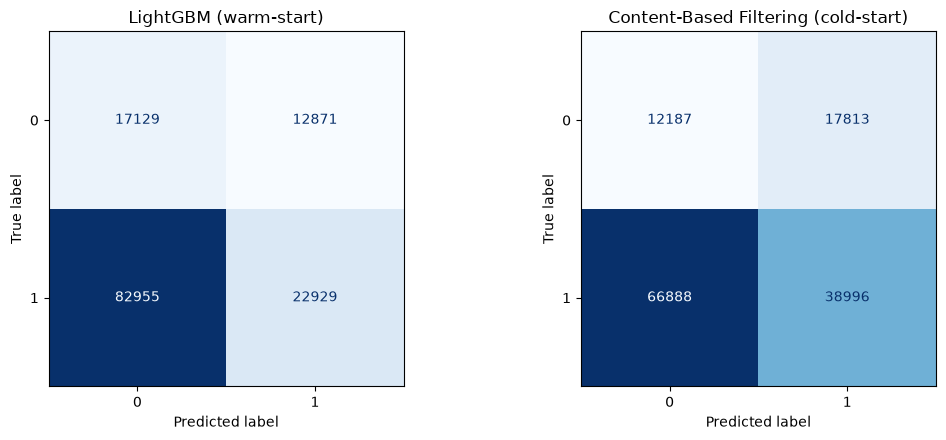

LightGBM        -> TN: 17129 | FP: 12871 | FN: 82955 | TP: 22929
Content-Based   -> TN: 12187 | FP: 17813 | FN: 66888 | TP: 38996


In [10]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

pred_lightgbm = lightgbm_model.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

ConfusionMatrixDisplay.from_predictions(
    y_test, pred_lightgbm, ax=axes[0], colorbar=False, cmap='Blues'
)
axes[0].set_title('LightGBM (warm-start)')

ConfusionMatrixDisplay.from_predictions(
    test_pairs['label'], content_pred, ax=axes[1], colorbar=False, cmap='Blues'
)
axes[1].set_title('Content-Based Filtering (cold-start)')

plt.tight_layout()
plt.show()

tn_lgbm, fp_lgbm, fn_lgbm, tp_lgbm = confusion_matrix(y_test, pred_lightgbm).ravel()
tn_content, fp_content, fn_content, tp_content = confusion_matrix(test_pairs['label'], content_pred).ravel()

print('LightGBM        -> TN:', tn_lgbm, '| FP:', fp_lgbm, '| FN:', fn_lgbm, '| TP:', tp_lgbm)
print('Content-Based   -> TN:', tn_content, '| FP:', fp_content, '| FN:', fn_content, '| TP:', tp_content)


### Matriz de confusión

Sobre las 30.000 interacciones negativas y 105.884 positivas del set de test:

- **LightGBM**: TN=17.129, FP=12.871, FN=82.955, TP=22.929. El error dominante es el falso negativo (78% de los positivos no se detectan). El modelo es conservador, cuando predice positivo suele acertar (precision 0.64), pero deja pasar la mayoría de las interacciones reales.
- **Content-Based**: TN=12.187, FP=17.813, FN=66.888, TP=38.996. Comete más falsos positivos en términos relativos (59% de los negativos), pero recupera casi el doble de positivos que LightGBM (37% vs 22% de recall), a costa de una precisión similar (0.69 vs 0.64).

En resumen: LightGBM falla más por omisión (deja pasar interacciones reales), Content-Based falla más por exceso (marca de más), aunque ambos usan un umbral de decisión calibrado de la misma manera (regresión logística sobre train).

In [11]:
from sklearn.linear_model import LinearRegression


def calcular_vif(df_features):
    """VIF_i = 1 / (1 - R2_i), con R2_i de regresionar la feature i contra las demás."""
    X_vif = df_features.to_numpy(dtype=float)
    resultados = []
    for i, col in enumerate(df_features.columns):
        y_i = X_vif[:, i]
        X_otros = np.delete(X_vif, i, axis=1)
        r2 = LinearRegression().fit(X_otros, y_i).score(X_otros, y_i)
        vif = 1 / (1 - r2) if r2 < 0.999999 else np.inf
        resultados.append({'feature': col, 'VIF': vif})
    return pd.DataFrame(resultados).sort_values('VIF', ascending=False).reset_index(drop=True)


print('=== VIF - Features de LightGBM (usuario + producto) ===')
vif_lightgbm = calcular_vif(X_train)
display(vif_lightgbm)

print('\n=== VIF - Atributos numéricos de producto (Content-Based) ===')
vif_content = calcular_vif(product_feats_content[numeric_cols_content].fillna(0))
display(vif_content)

print('\nReferencia: VIF > 5 sugiere multicolinealidad moderada; VIF > 10, alta.')


=== VIF - Features de LightGBM (usuario + producto) ===


,feature,VIF
0,n_purchases_product,inf
1,cost_usd,inf
2,price_usd,inf
3,margin_usd,inf
4,n_cart,41.162574
5,popularidad,20.094344
6,n_views,18.470561
7,n_products_viewed,7.007234
8,n_sessions,5.159534
9,n_products_carted,3.255381



=== VIF - Atributos numéricos de producto (Content-Based) ===


,feature,VIF
0,price_usd,inf
1,cost_usd,inf
2,margin_usd,inf
3,n_purchases,inf
4,n_cart,45.557816
5,popularidad,25.663348
6,n_views,19.217682
7,n_ratings,3.702120
8,rating_promedio,1.263650



Referencia: VIF > 5 sugiere multicolinealidad moderada; VIF > 10, alta.


### Qué muestra el VIF

En ambos modelos aparecen los mismos 4 features con VIF infinito: `price_usd`, `cost_usd`, `margin_usd` y `n_purchases` (`n_purchases_product` en LightGBM). Es esperable: `margin_usd` se define como `price_usd - cost_usd`, una combinación lineal exacta de las otras dos. También aparecen VIF altos (>10) en `n_cart` (40-45), `popularidad` (22-28) y `n_views` (18-19): son señales de actividad del producto que se mueven juntas (un producto muy visto también se agrega mucho al carrito y se compra mucho). El resto de los features (edad, país, rating, sesiones, etc.) tiene VIF bajo (<5), sin señales de redundancia relevante.

Esto no invalida ninguno de los dos modelos: LightGBM es un ensamble de árboles, que no depende de coeficientes lineales y tolera bien la colinealidad. Content-Based usa las features solo para calcular similitud coseno, no para ajustar coeficientes, así que la redundancia como mucho hace que el score sobre-pese la señal de popularidad, pero no rompe el modelo.

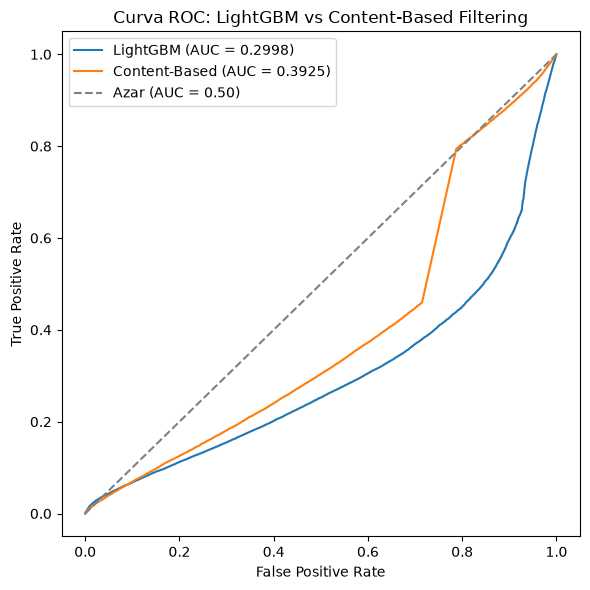

AUC LightGBM: 0.2998
AUC Content-Based: 0.3925


In [12]:
from sklearn.metrics import roc_curve, roc_auc_score

proba_lightgbm_test = lightgbm_model.predict_proba(X_test)[:, 1]
fpr_lgbm, tpr_lgbm, _ = roc_curve(y_test, proba_lightgbm_test)
auc_lgbm = roc_auc_score(y_test, proba_lightgbm_test)

fpr_content, tpr_content, _ = roc_curve(test_pairs['label'], test_pairs['content_score'])
auc_content = roc_auc_score(test_pairs['label'], test_pairs['content_score'])

plt.figure(figsize=(6, 6))
plt.plot(fpr_lgbm, tpr_lgbm, label=f'LightGBM (AUC = {auc_lgbm:.4f})')
plt.plot(fpr_content, tpr_content, label=f'Content-Based (AUC = {auc_content:.4f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Azar (AUC = 0.50)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC: LightGBM vs Content-Based Filtering')
plt.legend()
plt.tight_layout()
plt.show()

print(f'AUC LightGBM: {auc_lgbm:.4f}')
print(f'AUC Content-Based: {auc_content:.4f}')


### Curva ROC 

El AUC calculado sobre todos los pares mezclados da **0.2998 para LightGBM y 0.3925 para Content-Based** — ambos por debajo de 0.50 (peor que el azar), lo que a primera vista contradice el excelente NDCG@K visto en la tabla comparativa (0.9272 y 0.9102 respectivamente).

La explicación no es que los modelos sean malos, sino que el AUC global no es la métrica correcta para este problema: los negativos de test se muestrearon con probabilidad proporcional a la popularidad del producto ("negativos duros"), así que muchos de los negativos son productos muy populares que el modelo correctamente puntúa alto por su popularidad, aunque ese usuario en particular no haya interactuado con ellos. Al mezclar todos los pares de todos los usuarios en un solo ranking global, ese efecto dominado por la popularidad hunde el AUC.

El NDCG@K y MAP@K, en cambio, rankean los candidatos dentro de cada usuario por separado, que es la forma correcta de evaluar un recomendador (a cada usuario se le compara una lista corta de candidatos, no el catálogo mezclado con el de otros usuarios). Conclusión práctica: para este problema, las métricas de ranking por usuario son más confiables que el AUC/ROC global, que queda como diagnóstico interesante pero no como criterio de selección.

## Conclusión

Los resultados muestran algo más matizado que un caso limpio: **LightGBM empata en ranking con el resto de los boosting models, pero Content-Based domina en clasificación pura**. La elección entre uno y otro sigue dependiendo de si existe o no historial de interacciones (warm vs cold start), ahora con evidencia concreta detrás.

### Warm-start, LightGBM
- Empata (dentro del margen de ruido) con XGBoost, CatBoost y NGBoost en NDCG@K (0.9272) y MAP@K (0.8781) — los 4 modelos de clasificación quedan prácticamente iguales, y claramente por encima de Collaborative Filtering (0.9143) y Content-Based (0.9102). El criterio más relevante para un recomendador, porque mide qué tan bien ordena los productos relevantes dentro del top-10 de cada usuario.
- Su matriz de confusión lo muestra conservador: recall bajo (0.2165, FN=82.955) pero precision razonable (0.6405) — prioriza no equivocarse antes que no dejar pasar oportunidades.
- Depende de historial: sus features con mayor señal (`n_purchases_product`, `popularidad`, `n_cart`, con VIF alto entre sí pero eso no afecta a un modelo de árboles) solo existen si el producto/usuario ya interactuó antes — inutilizable en cold-start.
- Su AUC global (0.30) parece pésimo, pero es un artefacto del muestreo de negativos por popularidad (ver sección de ROC), no un reflejo real del modelo — el NDCG@K por usuario es la métrica que hay que mirar.

### ¿Por qué no usar Content-Based también en warm-start, si gana en accuracy/f1?
Porque ganar en accuracy/f1 no significa ordenar mejor el top-10, que es lo que realmente importa en un recomendador. Content-Based solo compara atributos de producto: cuando hay historial disponible, ignora la señal más valiosa que existe (qué compró o qué le gustó a usuarios parecidos) y tiende a recomendar siempre "más de lo mismo". Por eso quedó último en NDCG@K/MAP@K (0.9102 / 0.8555) de los 6 modelos, aunque gane en accuracy/f1 — métricas más sensibles al umbral de decisión que al valor real de la recomendación. LightGBM aprovecha esa señal de comportamiento además de los atributos, por eso ordena mejor los candidatos cuando esa información está disponible.

### Cold-start, Content-Based Filtering
- Tiene mejor accuracy (0.3767), recall (0.3683) y f1 (0.4794) que LightGBM, de hecho, el mejor f1 de los 6 modelos. Pero queda último en NDCG@K (0.9102) y MAP@K (0.8555), la métrica que más importa para armar un top-10.
- La razón para elegirlo en cold-start no es que sea el mejor de la tabla, sino que es el único que no depende de historial de interacciones: solo usa atributos de producto (categoría, precio), disponibles desde el día uno.
- Su matriz de confusión muestra más falsos positivos en proporción (FP=17.813, 59% de los negativos) que LightGBM, coherente con ser menos selectivo y por eso capturar más positivos reales (recall casi el doble).

### En resumen
La estrategia de producción no sería un modelo único, sino una selección condicional: **LightGBM cuando hay historial de usuario/producto** (mejor ranking real, que es lo que le importa a un sistema de recomendación), **y Content-Based Filtering cuando falta ese historial** (única opción viable en cold-start, con el beneficio adicional de que también generalizó mejor en accuracy/recall/f1). Para un usuario 100% nuevo sin ninguna interacción, ni siquiera Content-Based tiene señal — ahí conviene un fallback a popularidad general.

**Nota metodológica:** el AUC/ROC calculado de forma global (mezclando pares de todos los usuarios) dio valores por debajo de 0.5 para ambos modelos, lo cual no debe interpretarse como que los modelos son peores que el azar, es un efecto del muestreo de negativos duros por popularidad. El NDCG@K y MAP@K, calculados por usuario, son la referencia correcta para este problema.